# Hours worked per family type

In [3]:
import pandas as pd

df = pd.read_csv(
    "/Users/anapreciado/Desktop/github_repos/dataccion-agent/extraction/data/GED_PHOW_SEX_HHT_CHL_NB_A-remodelado-2026-04-05.csv"
)

In [4]:
df

,Área de referencia,Fuente,Tipo de hogar,Presencia de niños menores de 6 años,Año,Mujeres,Hombres
0,Argentina,"EFT - Encuesta Permanente de Hogares, Urbano",Total,Presencia de niños menores de 6 años: Total,2024,33.1,42.0
1,Argentina,"EFT - Encuesta Permanente de Hogares, Urbano",Total,Presencia de niños menores de 6 años: Si,2024,31.0,43.2
2,Argentina,"EFT - Encuesta Permanente de Hogares, Urbano",Total,Presencia de niños menores de 6 años: No,2024,33.8,41.6
3,Argentina,"EFT - Encuesta Permanente de Hogares, Urbano",Una persona,Presencia de niños menores de 6 años: Total,2024,36.4,39.8
4,Argentina,"EFT - Encuesta Permanente de Hogares, Urbano",Una persona,Presencia de niños menores de 6 años: No,2024,36.4,39.8
...,...,...,...,...,...,...,...
852,Uruguay,EFT - Encuesta Continua de Hogares Implantacion,Familia extendida,Número de niños menores de 6 años: Total,2024,33.0,38.6
853,Uruguay,EFT - Encuesta Continua de Hogares Implantacion,Familia extendida,Número de niños menores de 6 años: 0,2024,33.2,38.6
854,Uruguay,EFT - Encuesta Continua de Hogares Implantacion,Familia extendida,Número de niños menores de 6 años: 1,2024,32.6,38.6
855,Uruguay,EFT - Encuesta Continua de Hogares Implantacion,Familia extendida,Número de niños menores de 6 años: 2,2024,33.2,38.7


## Horas trabajadas, estructura familiar y presencia de niños pequeños

Este análisis examina cómo el tipo de hogar y la presencia de niños menores de 6 años afectan de forma diferenciada las horas semanales trabajadas por mujeres y hombres, revelando la "penalización maternal" en el mercado laboral.

In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

COLOR_F = '#E07B8A'
COLOR_M = '#4A7BB5'
COL_NINOS = 'Presencia de niños menores de 6 años'

# --- Parse the children column into two clean fields ---
# Format A: "Presencia de niños menores de 6 años: Si/No/Total"
# Format B: "Número de niños menores de 6 años: 0/1/2/3+/Total"

def parse_children(val):
    """Returns (metric_type, value_label)"""
    if 'Presencia' in val:
        v = val.split(': ', 1)[1].strip()
        return 'presencia', v          # Total, Si, No
    else:
        v = val.split(': ', 1)[1].strip()
        return 'numero', v             # Total, 0, 1, 2, 3+

df[['child_metric', 'child_val']] = df[COL_NINOS].apply(
    lambda x: pd.Series(parse_children(x))
)
df['brecha'] = df['Hombres'] - df['Mujeres']   # positive = men work more

countries = df['Área de referencia'].unique()
print(f"{len(countries)} países")
print("Tipos de hogar:", df['Tipo de hogar'].unique().tolist())
print("child_metric values:", df['child_metric'].unique())
print("child_val values:", df['child_val'].unique().tolist())
df.head(8)

22 países
Tipos de hogar: ['Total', 'Una persona', 'Pareja sin hijos', 'Pareja con hijos', 'Padre solo', 'Familia extendida']
child_metric values: ['presencia' 'numero']
child_val values: ['Total', 'Si', 'No', '0', '1', '2', '3+']


,Área de referencia,Fuente,Tipo de hogar,Presencia de niños menores de 6 años,Año,Mujeres,Hombres,child_metric,child_val,brecha
0,Argentina,"EFT - Encuesta Permanente de Hogares, Urbano",Total,Presencia de niños menores de 6 años: Total,2024,33.1,42.0,presencia,Total,8.9
1,Argentina,"EFT - Encuesta Permanente de Hogares, Urbano",Total,Presencia de niños menores de 6 años: Si,2024,31.0,43.2,presencia,Si,12.2
2,Argentina,"EFT - Encuesta Permanente de Hogares, Urbano",Total,Presencia de niños menores de 6 años: No,2024,33.8,41.6,presencia,No,7.8
3,Argentina,"EFT - Encuesta Permanente de Hogares, Urbano",Una persona,Presencia de niños menores de 6 años: Total,2024,36.4,39.8,presencia,Total,3.4
4,Argentina,"EFT - Encuesta Permanente de Hogares, Urbano",Una persona,Presencia de niños menores de 6 años: No,2024,36.4,39.8,presencia,No,3.4
5,Argentina,"EFT - Encuesta Permanente de Hogares, Urbano",Pareja sin hijos,Presencia de niños menores de 6 años: Total,2024,35.3,41.7,presencia,Total,6.4
6,Argentina,"EFT - Encuesta Permanente de Hogares, Urbano",Pareja sin hijos,Presencia de niños menores de 6 años: No,2024,35.3,41.7,presencia,No,6.4
7,Argentina,"EFT - Encuesta Permanente de Hogares, Urbano",Pareja con hijos,Presencia de niños menores de 6 años: Total,2024,32.0,42.9,presencia,Total,10.9


### 1. Brecha de horas por tipo de hogar (promedio regional)

¿En qué estructura familiar es mayor la diferencia entre horas trabajadas por hombres y mujeres?

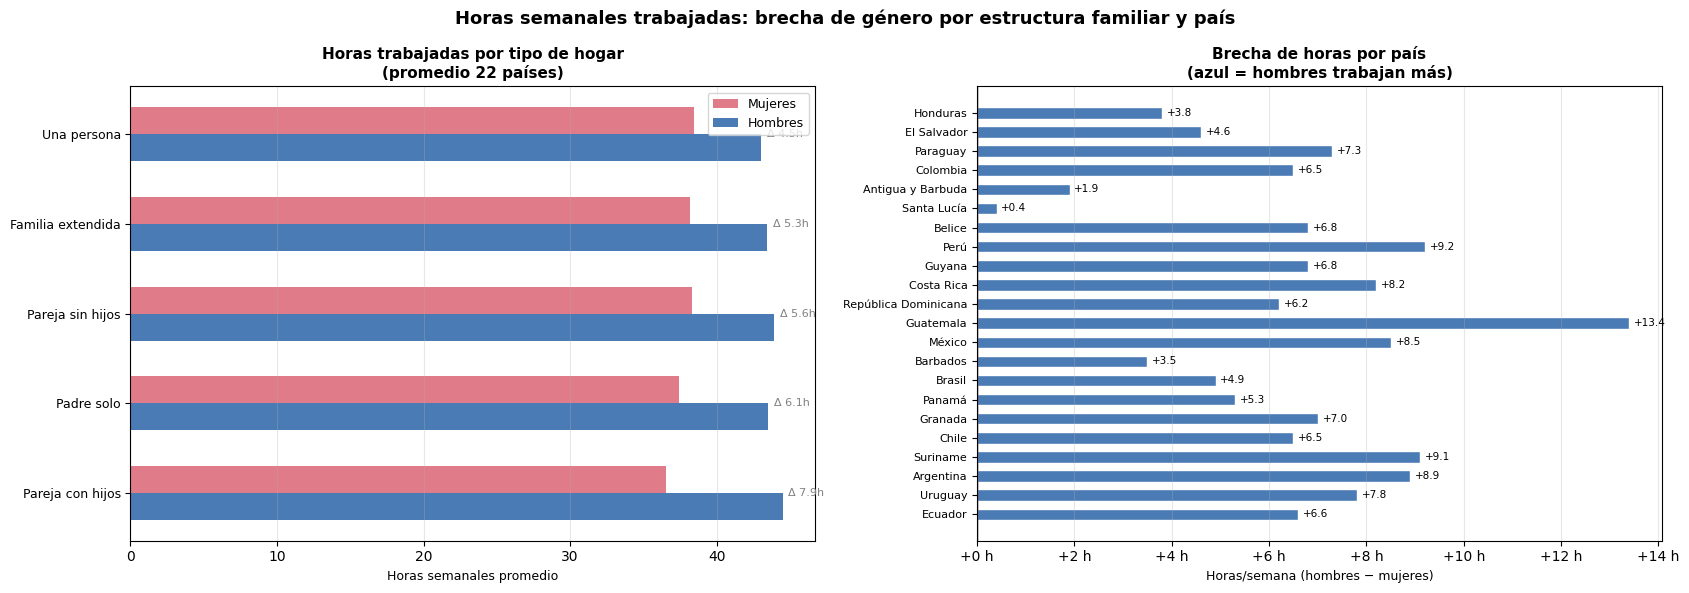

In [6]:
# Use presencia=Total to get the unconditional average per household type
hhtype = (
    df[(df['child_metric'] == 'presencia') & (df['child_val'] == 'Total')
       & (df['Tipo de hogar'] != 'Total')]
    .groupby('Tipo de hogar')[['Mujeres', 'Hombres', 'brecha']]
    .mean()
    .reset_index()
    .sort_values('brecha', ascending=False)
)

# Same for country-level reference (Total hogar, Total niños)
total_country = (
    df[(df['child_metric'] == 'presencia') & (df['child_val'] == 'Total')
       & (df['Tipo de hogar'] == 'Total')]
    .groupby('Área de referencia')[['Mujeres', 'Hombres', 'brecha']]
    .mean()
    .reset_index()
    .sort_values('Mujeres')
)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# --- Left: hours by household type ---
ax = axes[0]
y = np.arange(len(hhtype))
bw = 0.3
ax.barh(y + bw/2, hhtype['Mujeres'], bw, color=COLOR_F, label='Mujeres')
ax.barh(y - bw/2, hhtype['Hombres'], bw, color=COLOR_M, label='Hombres')
ax.set_yticks(y)
ax.set_yticklabels(hhtype['Tipo de hogar'], fontsize=9)
ax.set_xlabel('Horas semanales promedio', fontsize=9)
ax.set_title('Horas trabajadas por tipo de hogar\n(promedio 22 países)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)

# Annotate gap
for i, (_, row) in enumerate(hhtype.iterrows()):
    ax.text(max(row['Mujeres'], row['Hombres']) + 0.4, i,
            f'Δ {row["brecha"]:.1f}h', va='center', fontsize=8, color='gray')

# --- Right: gender gap per country (total, no filter) ---
ax2 = axes[1]
y2 = np.arange(len(total_country))
colors_gap = [COLOR_M if v > 0 else COLOR_F for v in total_country['brecha']]
ax2.barh(y2, total_country['brecha'], color=colors_gap, height=0.6, edgecolor='white')
ax2.axvline(0, color='black', linewidth=1)
ax2.set_yticks(y2)
ax2.set_yticklabels(total_country['Área de referencia'], fontsize=8)
ax2.set_xlabel('Horas/semana (hombres − mujeres)', fontsize=9)
ax2.set_title('Brecha de horas por país\n(azul = hombres trabajan más)', fontsize=11, fontweight='bold')
ax2.xaxis.set_major_formatter(mticker.FormatStrFormatter('%+.0f h'))
ax2.grid(axis='x', alpha=0.3)
for bar, val in zip(ax2.patches, total_country['brecha']):
    xpos = val + (0.1 if val >= 0 else -0.1)
    ha = 'left' if val >= 0 else 'right'
    ax2.text(xpos, bar.get_y() + bar.get_height() / 2,
             f'{val:+.1f}', va='center', ha=ha, fontsize=7.5)

fig.suptitle('Horas semanales trabajadas: brecha de género por estructura familiar y país',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('hours_by_hhtype_country.png', dpi=150, bbox_inches='tight')
plt.show()

### 2. La penalización maternal: efecto de tener niños menores de 6 años en las horas trabajadas

Comparación de horas trabajadas con y sin presencia de niños menores de 6 años, por género. La diferencia muestra quién absorbe el cuidado.

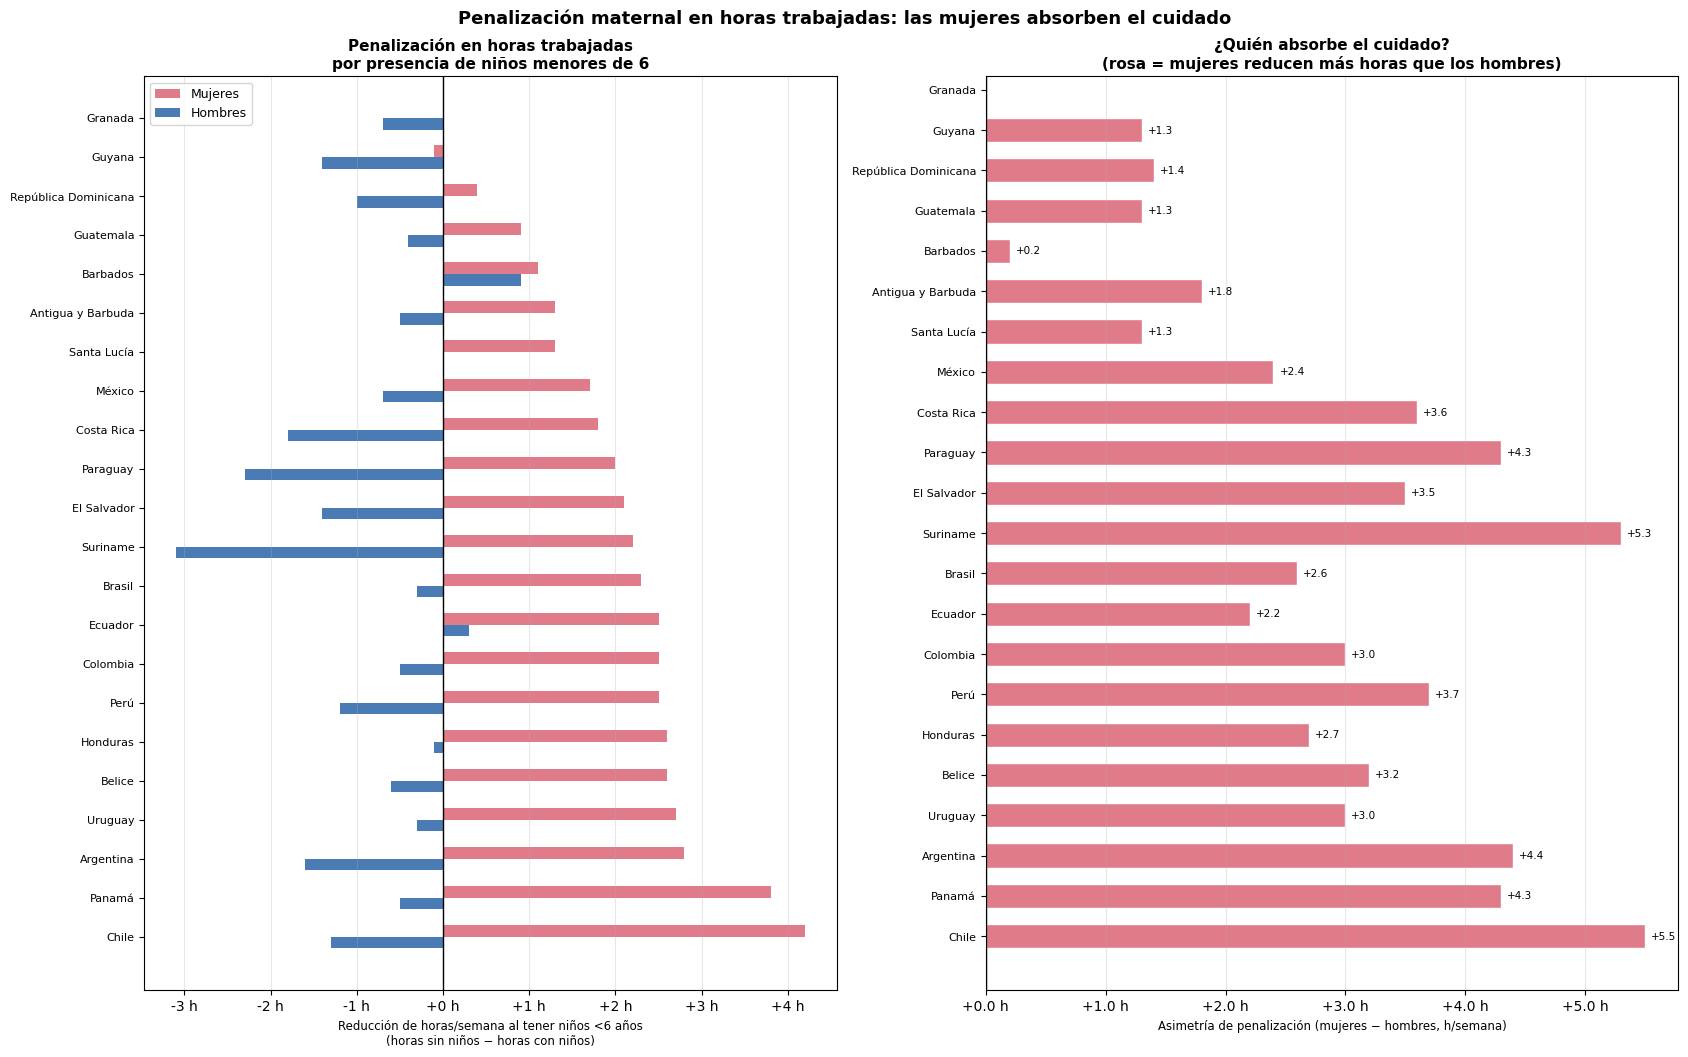

Promedio regional:
  Penalización mujeres: 2.06 h/semana menos al tener niños <6
  Penalización hombres: -0.84 h/semana
  Asimetría promedio:   2.90 h/semana


In [7]:
# Child penalty = hours(No niños) - hours(Sí niños)  — positive means fewer hours when children present
presence = (
    df[(df['child_metric'] == 'presencia') & (df['child_val'].isin(['Si', 'No']))
       & (df['Tipo de hogar'] == 'Total')]
    .groupby(['Área de referencia', 'child_val'])[['Mujeres', 'Hombres']]
    .mean()
    .reset_index()
)

# Pivot to get Si / No side by side
piv = presence.pivot(index='Área de referencia', columns='child_val', values=['Mujeres', 'Hombres'])
piv.columns = ['_'.join(c) for c in piv.columns]
piv['penalizacion_mujeres'] = piv['Mujeres_No'] - piv['Mujeres_Si']   # + = fewer hours with kids
piv['penalizacion_hombres'] = piv['Hombres_No'] - piv['Hombres_Si']
piv['asimetria'] = piv['penalizacion_mujeres'] - piv['penalizacion_hombres']  # + = women penalised more
piv = piv.sort_values('penalizacion_mujeres', ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(17, max(6, len(piv) * 0.42 + 1.5)))

# --- Left: penalty bars side by side ---
ax = axes[0]
y = np.arange(len(piv))
bw = 0.3
bars_f = ax.barh(y + bw/2, piv['penalizacion_mujeres'], bw, color=COLOR_F, label='Mujeres')
bars_m = ax.barh(y - bw/2, piv['penalizacion_hombres'], bw, color=COLOR_M, label='Hombres')
ax.axvline(0, color='black', linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(piv['Área de referencia'], fontsize=8)
ax.set_xlabel('Reducción de horas/semana al tener niños <6 años\n(horas sin niños − horas con niños)', fontsize=8.5)
ax.set_title('Penalización en horas trabajadas\npor presencia de niños menores de 6', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%+.0f h'))

# --- Right: asymmetry (women penalised more than men?) ---
ax2 = axes[1]
colors_asym = [COLOR_F if v > 0 else COLOR_M for v in piv['asimetria']]
ax2.barh(y, piv['asimetria'], color=colors_asym, height=0.6, edgecolor='white')
ax2.axvline(0, color='black', linewidth=1)
ax2.set_yticks(y)
ax2.set_yticklabels(piv['Área de referencia'], fontsize=8)
ax2.set_xlabel('Asimetría de penalización (mujeres − hombres, h/semana)', fontsize=8.5)
ax2.set_title('¿Quién absorbe el cuidado?\n(rosa = mujeres reducen más horas que los hombres)', fontsize=11, fontweight='bold')
ax2.xaxis.set_major_formatter(mticker.FormatStrFormatter('%+.1f h'))
ax2.grid(axis='x', alpha=0.3)
for bar, val in zip(ax2.patches, piv['asimetria']):
    if pd.notna(val):
        xpos = val + (0.05 if val >= 0 else -0.05)
        ha = 'left' if val >= 0 else 'right'
        ax2.text(xpos, bar.get_y() + bar.get_height() / 2,
                 f'{val:+.1f}', va='center', ha=ha, fontsize=7.5)

fig.suptitle('Penalización maternal en horas trabajadas: las mujeres absorben el cuidado',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('child_penalty_hours.png', dpi=150, bbox_inches='tight')
plt.show()

print("Promedio regional:")
print(f"  Penalización mujeres: {piv['penalizacion_mujeres'].mean():.2f} h/semana menos al tener niños <6")
print(f"  Penalización hombres: {piv['penalizacion_hombres'].mean():.2f} h/semana")
print(f"  Asimetría promedio:   {piv['asimetria'].mean():.2f} h/semana")

### 3. Efecto dosis-respuesta: horas trabajadas según número de niños menores de 6

¿Cada niño adicional reduce más las horas de las mujeres que las de los hombres?

/var/folders/mq/1yp0hqvn7mg6cbdtcfjwn9fm0000gn/T/ipykernel_31050/4108430491.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dose.groupby('child_val')[['Mujeres', 'Hombres']]


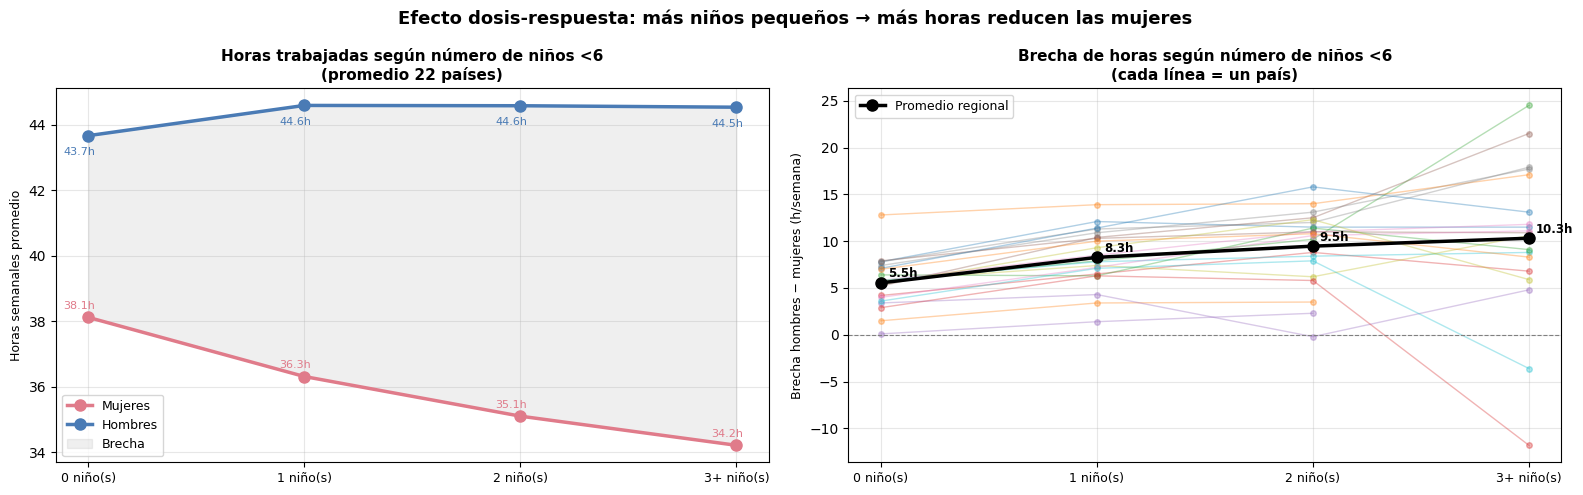

In [8]:
num_order = ['0', '1', '2', '3+']

dose = (
    df[(df['child_metric'] == 'numero') & (df['child_val'].isin(num_order))
       & (df['Tipo de hogar'] == 'Total')]
    .groupby(['Área de referencia', 'child_val'])[['Mujeres', 'Hombres']]
    .mean()
    .reset_index()
)
dose['child_val'] = pd.Categorical(dose['child_val'], categories=num_order, ordered=True)
dose = dose.sort_values(['Área de referencia', 'child_val'])

# Regional average
dose_avg = (
    dose.groupby('child_val')[['Mujeres', 'Hombres']]
    .mean()
    .reset_index()
)

# --- Plot 1: regional average line chart ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(dose_avg['child_val'], dose_avg['Mujeres'], '-o', color=COLOR_F, linewidth=2.5,
        markersize=8, label='Mujeres')
ax.plot(dose_avg['child_val'], dose_avg['Hombres'], '-o', color=COLOR_M, linewidth=2.5,
        markersize=8, label='Hombres')

# Shade the gap
ax.fill_between(range(len(dose_avg)), dose_avg['Mujeres'], dose_avg['Hombres'],
                alpha=0.12, color='gray', label='Brecha')

for i, row in dose_avg.iterrows():
    ax.annotate(f'{row["Mujeres"]:.1f}h', (i, row['Mujeres']),
                textcoords='offset points', xytext=(-18, 6), fontsize=8, color=COLOR_F)
    ax.annotate(f'{row["Hombres"]:.1f}h', (i, row['Hombres']),
                textcoords='offset points', xytext=(-18, -14), fontsize=8, color=COLOR_M)

ax.set_xticks(range(len(dose_avg)))
ax.set_xticklabels([f'{v} niño(s)' for v in dose_avg['child_val']], fontsize=9)
ax.set_ylabel('Horas semanales promedio', fontsize=9)
ax.set_title('Horas trabajadas según número de niños <6\n(promedio 22 países)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# --- Plot 2: brecha (gap) per number of children, each country as a line ---
ax2 = axes[1]
for country in countries:
    sub = dose[dose['Área de referencia'] == country].copy()
    if len(sub) < 2:
        continue
    gap_series = sub['Hombres'].values - sub['Mujeres'].values
    x_vals = [num_order.index(v) for v in sub['child_val'].values]
    ax2.plot(x_vals, gap_series, '-o', alpha=0.35, linewidth=1, markersize=4)

# Regional average gap on top
gap_avg = dose_avg['Hombres'] - dose_avg['Mujeres']
ax2.plot(range(len(dose_avg)), gap_avg, '-o', color='black', linewidth=2.5,
         markersize=8, label='Promedio regional', zorder=10)
for i, val in enumerate(gap_avg):
    ax2.annotate(f'{val:.1f}h', (i, val), textcoords='offset points',
                 xytext=(5, 4), fontsize=8.5, fontweight='bold')

ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax2.set_xticks(range(len(num_order)))
ax2.set_xticklabels([f'{v} niño(s)' for v in num_order], fontsize=9)
ax2.set_ylabel('Brecha hombres − mujeres (h/semana)', fontsize=9)
ax2.set_title('Brecha de horas según número de niños <6\n(cada línea = un país)', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

fig.suptitle('Efecto dosis-respuesta: más niños pequeños → más horas reducen las mujeres',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dose_response_children.png', dpi=150, bbox_inches='tight')
plt.show()

### 4. Mapa de calor: brecha de género (h/semana) por tipo de hogar y país

¿En qué combinación de país × estructura familiar es mayor la desventaja horaria de las mujeres?

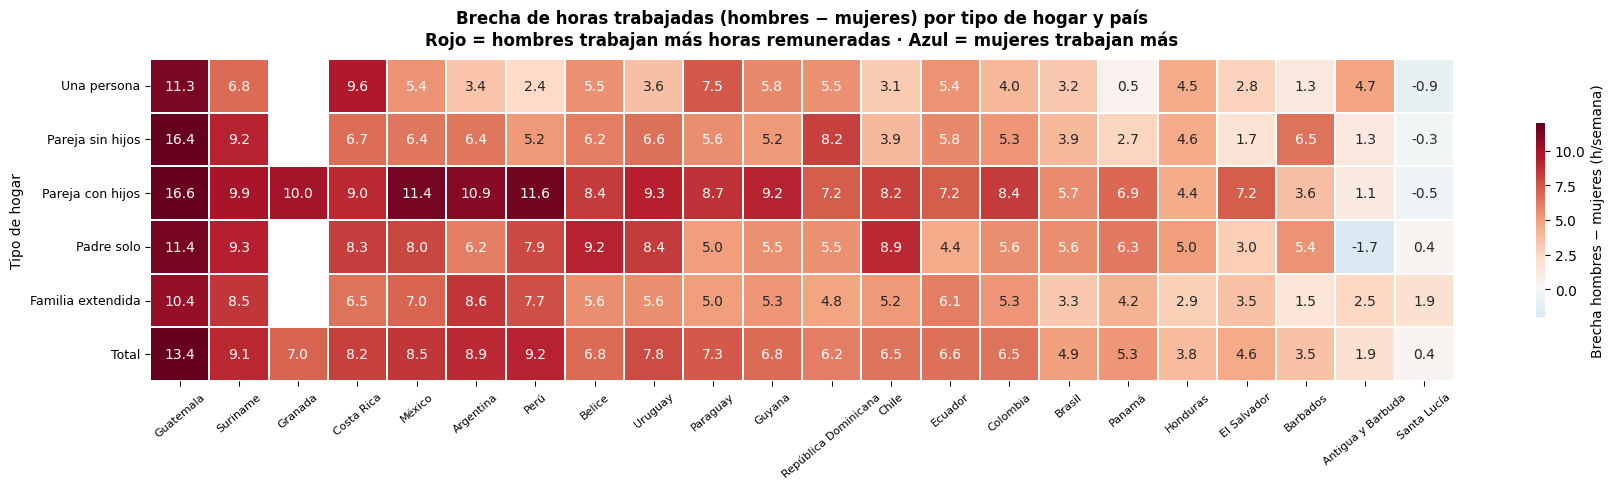

In [9]:
hh_gap = (
    df[(df['child_metric'] == 'presencia') & (df['child_val'] == 'Total')]
    .groupby(['Área de referencia', 'Tipo de hogar'])['brecha']
    .mean()
    .reset_index()
)

pivot_hh = hh_gap.pivot(index='Tipo de hogar', columns='Área de referencia', values='brecha')
# Order rows by mean gap
row_order = ['Una persona', 'Pareja sin hijos', 'Pareja con hijos', 'Padre solo',
             'Familia extendida', 'Total']
pivot_hh = pivot_hh.reindex([r for r in row_order if r in pivot_hh.index])
# Sort columns by mean gap
pivot_hh = pivot_hh[pivot_hh.mean().sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(
    pivot_hh,
    annot=True, fmt='.1f',
    cmap='RdBu_r',
    center=0,
    vmin=-2, vmax=12,
    linewidths=0.3, linecolor='white',
    cbar_kws={'label': 'Brecha hombres − mujeres (h/semana)', 'shrink': 0.6},
    ax=ax
)
ax.set_xlabel('')
ax.set_ylabel('Tipo de hogar', fontsize=10)
ax.set_title('Brecha de horas trabajadas (hombres − mujeres) por tipo de hogar y país\n'
             'Rojo = hombres trabajan más horas remuneradas · Azul = mujeres trabajan más',
             fontsize=12, fontweight='bold', pad=10)
ax.tick_params(axis='x', labelsize=8, rotation=40)
ax.tick_params(axis='y', labelsize=9, rotation=0)

plt.tight_layout()
plt.savefig('hours_gap_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 5. El nudo: interacción entre tipo de hogar y presencia de niños pequeños

¿Dónde se amplifica más la brecha? En las parejas con hijos, la combinación de estructura familiar y niños menores de 6 es el escenario más desigual.

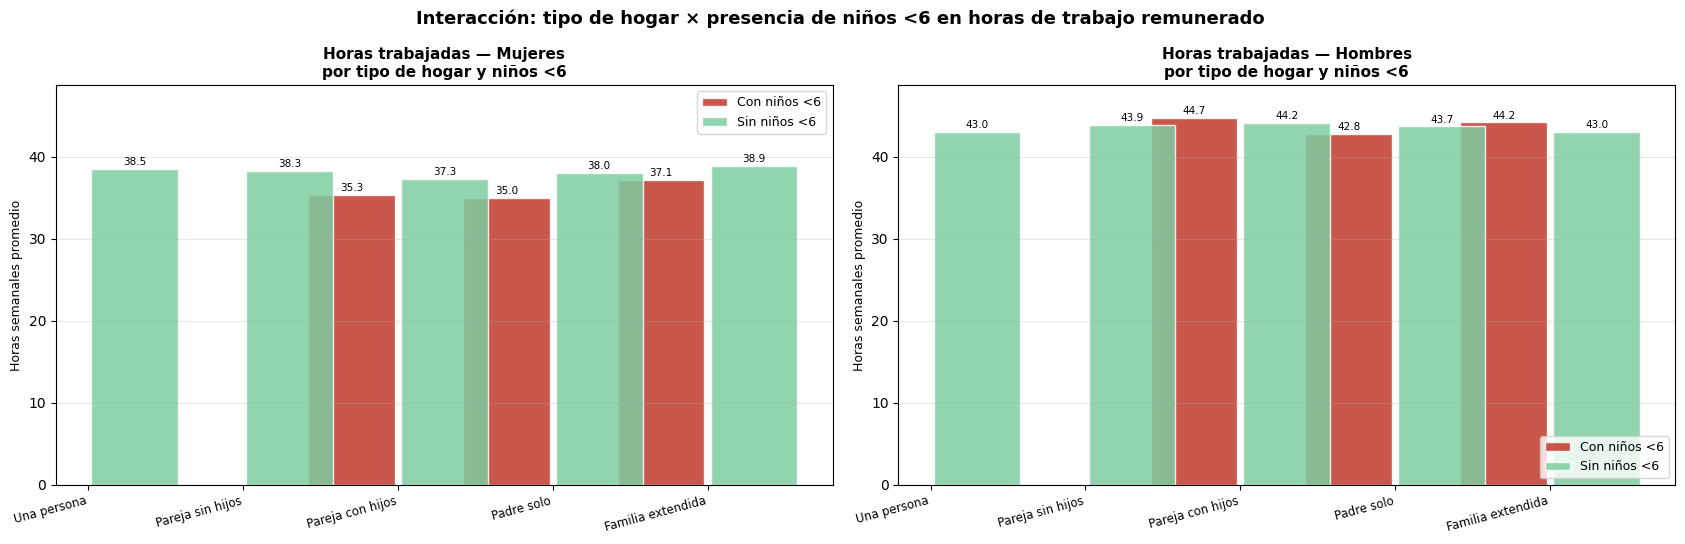

Brecha promedio (hombres − mujeres) por escenario:
  Una persona          | Sin niños <6    | Δ +4.54 h/semana
  Pareja sin hijos     | Sin niños <6    | Δ +5.60 h/semana
  Pareja con hijos     | Sin niños <6    | Δ +6.87 h/semana
  Pareja con hijos     | Con niños <6    | Δ +9.47 h/semana
  Padre solo           | Sin niños <6    | Δ +5.67 h/semana
  Padre solo           | Con niños <6    | Δ +7.74 h/semana
  Familia extendida    | Sin niños <6    | Δ +4.15 h/semana
  Familia extendida    | Con niños <6    | Δ +7.04 h/semana


In [10]:
hhtype_ordered = ['Una persona', 'Pareja sin hijos', 'Pareja con hijos', 'Padre solo', 'Familia extendida']
child_labels = {'Si': 'Con niños <6', 'No': 'Sin niños <6'}

interact = (
    df[(df['child_metric'] == 'presencia') & (df['child_val'].isin(['Si', 'No']))
       & (df['Tipo de hogar'].isin(hhtype_ordered))]
    .groupby(['Tipo de hogar', 'child_val'])[['Mujeres', 'Hombres', 'brecha']]
    .mean()
    .reset_index()
)
interact['Tipo de hogar'] = pd.Categorical(interact['Tipo de hogar'], categories=hhtype_ordered, ordered=True)
interact = interact.sort_values(['Tipo de hogar', 'child_val'])

# --- Grouped plot: one group per household type, two bars per group (Si/No) ---
fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))

x = np.arange(len(hhtype_ordered))
bw = 0.2
offsets = {'Si': -bw*1.5, 'No': bw*1.5}
child_colors = {'Si': '#C0392B', 'No': '#7DCEA0'}   # red = children present, green = no children

for ax_idx, (gender_col, gender_label, base_color) in enumerate([
    ('Mujeres', 'Mujeres', COLOR_F),
    ('Hombres', 'Hombres', COLOR_M),
]):
    ax = axes[ax_idx]
    for child_val, offset in offsets.items():
        sub = interact[interact['child_val'] == child_val]
        sub = sub.set_index('Tipo de hogar').reindex(hhtype_ordered)
        ax.bar(x + offset, sub[gender_col], bw * 2.8, color=child_colors[child_val],
               label=child_labels[child_val], alpha=0.85, edgecolor='white')
        for i, val in enumerate(sub[gender_col]):
            if pd.notna(val):
                ax.text(i + offset, val + 0.2, f'{val:.1f}', ha='center', va='bottom', fontsize=7.5)

    ax.set_xticks(x)
    ax.set_xticklabels(hhtype_ordered, fontsize=8.5, rotation=15, ha='right')
    ax.set_ylabel('Horas semanales promedio', fontsize=9)
    ax.set_title(f'Horas trabajadas — {gender_label}\npor tipo de hogar y niños <6', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, max(interact['Mujeres'].max(), interact['Hombres'].max()) + 4)

fig.suptitle('Interacción: tipo de hogar × presencia de niños <6 en horas de trabajo remunerado',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('interaction_hhtype_children.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary: amplification of the gap
print("Brecha promedio (hombres − mujeres) por escenario:")
for _, row in interact.iterrows():
    print(f"  {row['Tipo de hogar']:20s} | {child_labels[row['child_val']]:15s} | Δ {row['brecha']:+.2f} h/semana")